 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

 Load Dataset

In [2]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [3]:
print("🔍 بررسی اولیه داده‌ها:")
print(f"سطر و ستون: {df.shape}")
print(f"\nنمونه‌ای از داده‌ها:")
print(df.head())
print(f"\nاطلاعات ستون‌ها:")
print(df.info())
print(f"\nآمار توصیفی:")
print(df.describe())

🔍 بررسی اولیه داده‌ها:
سطر و ستون: (569, 31)

نمونه‌ای از داده‌ها:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension

Data Cleaning

In [4]:
print("\n🧹 پاکسازی داده‌ها:")

# بررسی مقادیر گمشده
print("مقادیر گمشده در هر ستون:")
print(df.isnull().sum())


🧹 پاکسازی داده‌ها:
مقادیر گمشده در هر ستون:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [5]:
# بررسی داده‌های تکراری
duplicates = df.duplicated().sum()
print(f"تعداد داده‌های تکراری: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)

تعداد داده‌های تکراری: 0


Exploratory Data Analysis


📊 تحلیل اکتشافی داده‌ها (EDA):


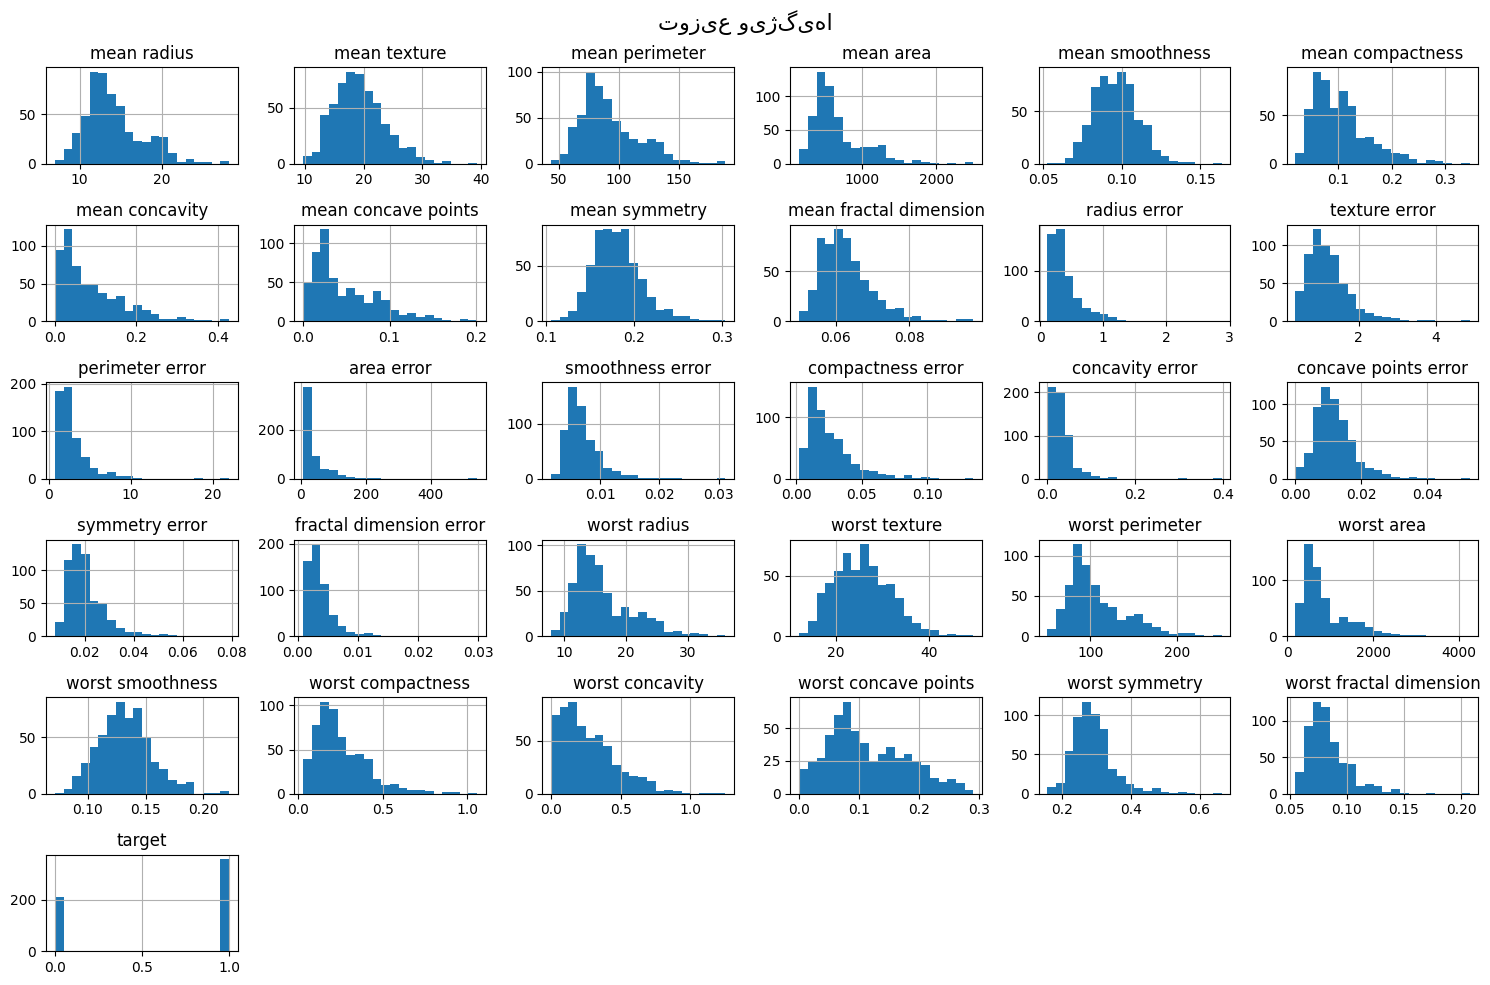

In [8]:
print("\n📊 تحلیل اکتشافی داده‌ها (EDA):")

# هیستوگرام تمام ویژگی‌ها
df.hist(figsize=(15, 10), bins=20)
plt.suptitle('توزیع ویژگی‌ها', fontsize=16)
plt.tight_layout()
plt.show()



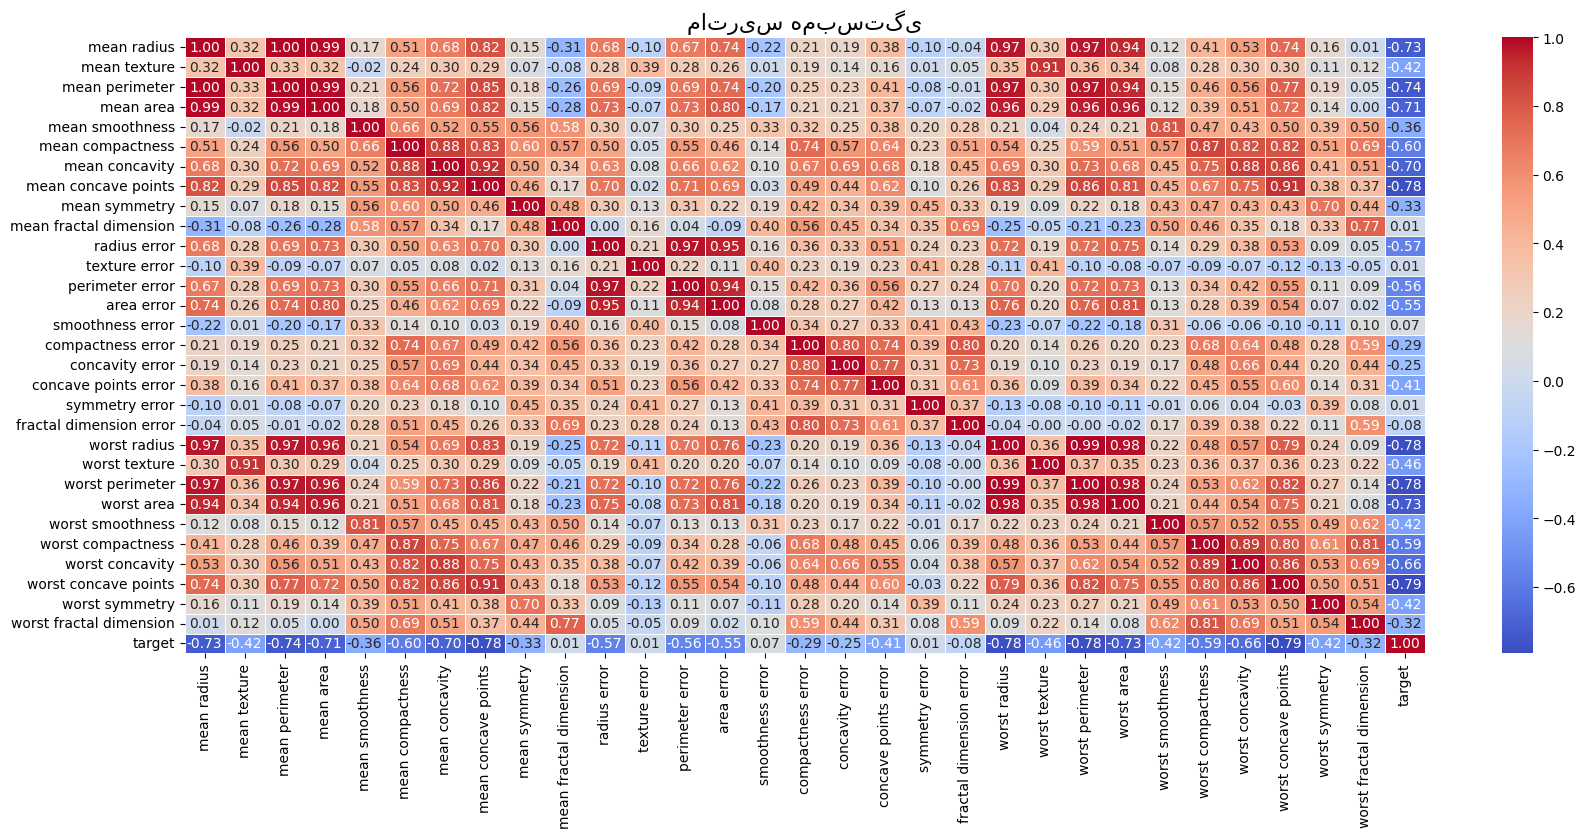

In [19]:
# بررسی همبستگی
plt.figure(figsize=(20, 8))
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('ماتریس همبستگی', fontsize=16)
plt.show()

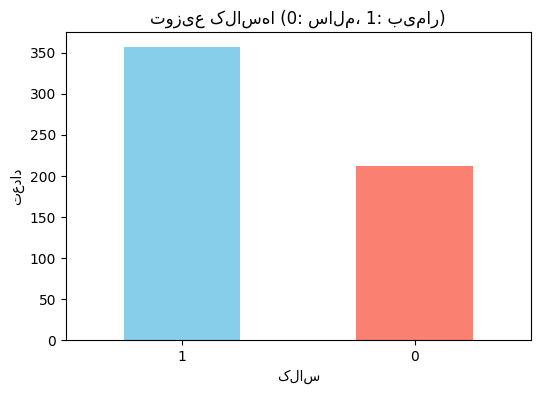

In [20]:
# توزیع کلاس‌ها (متعادل بودن داده‌ها)
plt.figure(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('توزیع کلاس‌ها (0: سالم، 1: بیمار)')
plt.xlabel('کلاس')
plt.ylabel('تعداد')
plt.xticks(rotation=0)
plt.show()

 Prepare Data for Modeling

In [21]:
print("\n⚙️ آماده‌سازی داده برای مدل‌سازی:")


⚙️ آماده‌سازی داده برای مدل‌سازی:


In [22]:
# جدا کردن ویژگی‌ها و برچسب
X = df.drop('target', axis=1)
y = df['target']

In [23]:
# تقسیم داده به آموزش و تست
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
# استانداردسازی داده‌ها
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
print(f"داده آموزش: {X_train.shape}")
print(f"داده تست: {X_test.shape}")
print(f"توزیع کلاس در داده آموزش: {np.bincount(y_train)}")
print(f"توزیع کلاس در داده تست: {np.bincount(y_test)}")

داده آموزش: (455, 30)
داده تست: (114, 30)
توزیع کلاس در داده آموزش: [170 285]
توزیع کلاس در داده تست: [42 72]


Machine Learning Models

In [26]:
print("\n🤖 آموزش مدل‌های یادگیری ماشین:")


🤖 آموزش مدل‌های یادگیری ماشین:


In [27]:
# تعریف مدل‌ها
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier()
}

In [28]:
results = {}
for name, model in models.items():
    # آموزش مدل
    model.fit(X_train_scaled, y_train)

    # پیش‌بینی
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None

    # ارزیابی
    accuracy = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }

    print(f"\n✅ {name}:")
    print(f"   دقت: {accuracy:.4f}")
    print(f"   دقت اعتبارسنجی متقابل: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

    # گزارش طبقه‌بندی
    print("\n   گزارش طبقه‌بندی:")
    print(classification_report(y_test, y_pred))


✅ Logistic Regression:
   دقت: 0.9825
   دقت اعتبارسنجی متقابل: 0.9802 (±0.0128)

   گزارش طبقه‌بندی:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


✅ Decision Tree:
   دقت: 0.9123
   دقت اعتبارسنجی متقابل: 0.9099 (±0.0189)

   گزارش طبقه‌بندی:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114


✅ Random Forest:
   دقت: 0.9561
   دقت اعتبارسنجی متقابل: 0.9538 (±0.0235)

   گزارش طبقه‌بندی:
              precision    recall  f1-score   sup

Model Comparison

In [29]:
print("\n📈 مقایسه مدل‌ها:")


📈 مقایسه مدل‌ها:


In [30]:
# ایجاد DataFrame برای نتایج
results_df = pd.DataFrame([
    {
        'Model': name,
        'Test Accuracy': results[name]['accuracy'],
        'CV Accuracy Mean': results[name]['cv_mean'],
        'CV Accuracy Std': results[name]['cv_std']
    }
    for name in results
])

print(results_df.sort_values('Test Accuracy', ascending=False))


                 Model  Test Accuracy  CV Accuracy Mean  CV Accuracy Std
0  Logistic Regression       0.982456          0.980220         0.012815
3                  SVM       0.982456          0.971429         0.017855
2        Random Forest       0.956140          0.953846         0.023466
4                  KNN       0.956140          0.967033         0.020850
1        Decision Tree       0.912281          0.909890         0.018906


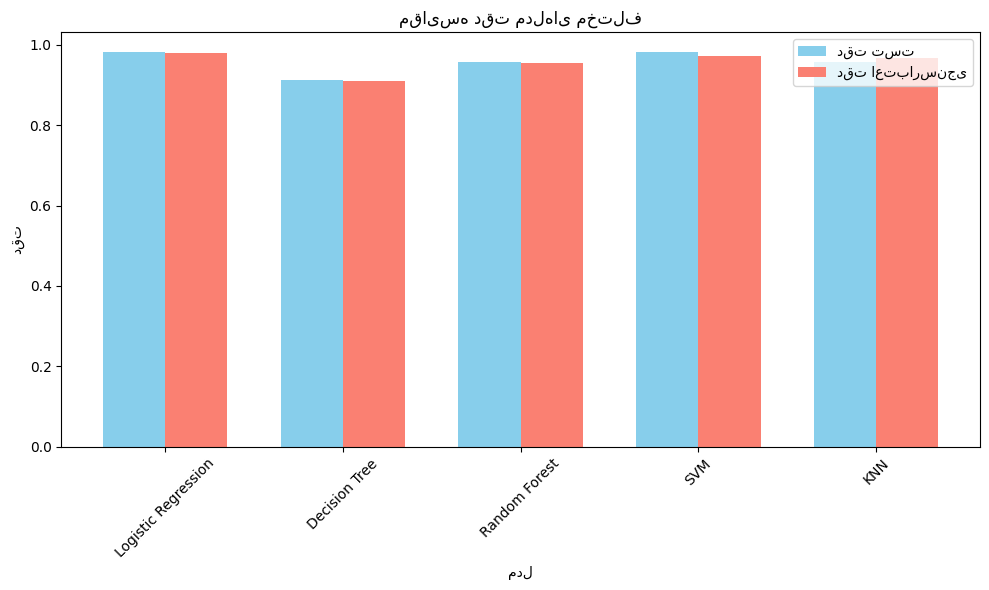

In [31]:
# نمودار مقایسه دقت مدل‌ها
plt.figure(figsize=(10, 6))
models_list = list(results.keys())
accuracy_scores = [results[m]['accuracy'] for m in models_list]
cv_scores = [results[m]['cv_mean'] for m in models_list]

x = np.arange(len(models_list))
width = 0.35

plt.bar(x - width/2, accuracy_scores, width, label='دقت تست', color='skyblue')
plt.bar(x + width/2, cv_scores, width, label='دقت اعتبارسنجی', color='salmon')

plt.xlabel('مدل')
plt.ylabel('دقت')
plt.title('مقایسه دقت مدل‌های مختلف')
plt.xticks(x, models_list, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

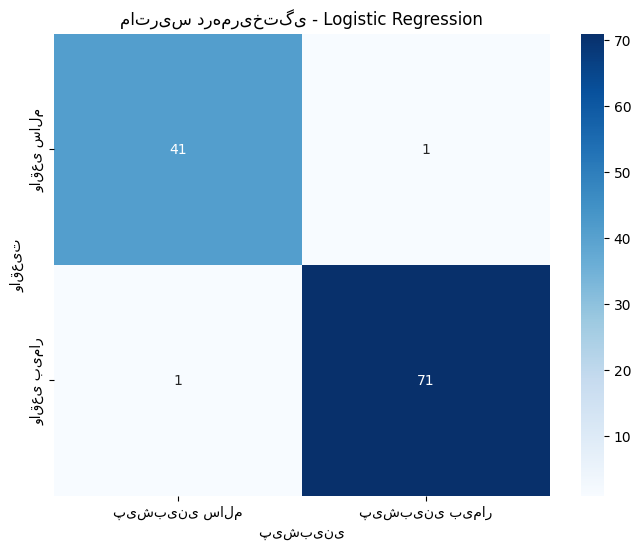

In [32]:
# ماتریس درهم‌ریختگی برای بهترین مدل
best_model_name = results_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['پیش‌بینی سالم', 'پیش‌بینی بیمار'],
            yticklabels=['واقعی سالم', 'واقعی بیمار'])
plt.title(f'ماتریس درهم‌ریختگی - {best_model_name}')
plt.ylabel('واقعیت')
plt.xlabel('پیش‌بینی')
plt.show()

Feature Importance (برای مدل‌های درختی)

In [36]:
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
    plt.title('مهم‌ترین ویژگی‌ها در پیش‌بینی')
    plt.tight_layout()
    plt.show()

    print("\n🎯 مهم‌ترین ویژگی‌ها:")
    print(feature_importance.head(10))

Hyperparameter Tuning

In [37]:
print("\n⚡ تنظیم هایپرپارامترها (برای بهترین مدل):")

# مثال برای Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
print(f"بهترین پارامترها: {grid_search.best_params_}")
print(f"بهترین دقت: {grid_search.best_score_:.4f}")


⚡ تنظیم هایپرپارامترها (برای بهترین مدل):
بهترین پارامترها: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
بهترین دقت: 0.9604


Save and Report

In [38]:
print("\n💾 ذخیره نتایج:")

# ذخیره مدل
import joblib
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# ذخیره نتایج در فایل CSV
results_df.to_csv('model_comparison.csv', index=False)

print("✅ پروژه با موفقیت تکمیل شد!")
print(f"🔝 بهترین مدل: {best_model_name} با دقت {results[best_model_name]['accuracy']:.4f}")


💾 ذخیره نتایج:
✅ پروژه با موفقیت تکمیل شد!
🔝 بهترین مدل: Logistic Regression با دقت 0.9825
